In [23]:
import pandas as pd # 파일입력(read_excel), 교차표(crosstab), 원핫인코딩(get_dummies)
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split # 훈련셋과 시험셋 분리 함수
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential, save_model, load_model
#과적합을 줄이기 위한 방법: dropout, 배치정규화, L2 정규화
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization 
from tensorflow.keras.regularizers import l2
# 데이터 불균형 극복 5.5:4.5 => 5:5
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt # 모델 학습과정 살펴보기
from sklearn.metrics import confusion_matrix # 혼동행렬

```
age: 나이 (년 단위)
sex: 성별 (1 = 남성, 0 = 여성)
cp (Chest Pain Type): 흉통의 유형 (0~3 값, 일반 협심증부터 무증상까지 분류)
trestbps: 안정 시 혈압 (mmHg)
chol: 혈청 콜레스테롤 수치 (mg/dl)
fbs (Fasting Blood Sugar): 공복 혈당이 120 mg/dl 초과인지 여부 (1 = 참, 0 = 거짓)
restecg: 안정 시 심전도(ECG) 결과 (0~2)
thalach: 운동 시 달성한 최대 심박수
exang: 운동 유발 협심증 여부 (1 = 있음, 0 = 없음)
oldpeak: 휴식기에 비해 운동 시 나타나는 ST 부위 하강(ST depression) 정도
slope: 최고 운동 시 ST 세그먼트의 기울기ca: 형광투시법으로 색칠된 주요 혈관 수 (0~3개)
thal: 지중해빈혈 등 혈액 질환 여부 (정상, 고정 결함, 가역적 결함 등)
target (Diagnosis): 심장질환 진단 결과 (0 = 정상, 1 = 심장질환 있음)
```

# 이진분류(로지스틱 회귀분석)
- 1. 데이터셋 생성 & 전처리
    * 엑셀 -> 데이터프레임 -> ?처리(결측치로 전환하여 결측치처리) -> X, y분리
        -> X변수의 scale조정 -> train_test_split()을 이용하여 학습셋과 테스트셋을 분리
- 2. 모델 생성(입력13,타겟1) - 과적합 고려 & 학습과정설정 & 학습
- 3. 모델 평가(그래프, 평가, 혼동행렬=교차표)
- 4. 모델 사용

## 1. 데이터셋 생성 & 전처리

In [24]:
df = pd.read_excel('data/heart-disease.xlsx',
                  # sheet_name='processed.cleveland'
                  )
df.head()

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,0,108,1,1.5,2,3,3,1
2,67,1,4,120,?,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           303 non-null    int64  
 1   sex           303 non-null    int64  
 2   cp            303 non-null    int64  
 3   treshtbps     303 non-null    int64  
 4   chol          303 non-null    object 
 5   fbs           303 non-null    int64  
 6   restecg       303 non-null    int64  
 7   thalach       303 non-null    int64  
 8   exang         303 non-null    int64  
 9   oldpeak       303 non-null    float64
 10  slope         303 non-null    int64  
 11  ca            303 non-null    object 
 12  hsl           303 non-null    object 
 13  heartDisease  303 non-null    int64  
dtypes: float64(1), int64(10), object(3)
memory usage: 33.3+ KB


In [26]:
df.isnull().sum()

age             0
sex             0
cp              0
treshtbps       0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
hsl             0
heartDisease    0
dtype: int64

In [27]:
df.isin(['?']).sum()

age             0
sex             0
cp              0
treshtbps       0
chol            1
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              4
hsl             2
heartDisease    0
dtype: int64

In [28]:
df[(df['chol']=='?') | (df['ca']=='?') | (df['hsl']=='?') ]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
2,67,1,4,120,?,0,2,129,1,2.6,2,2,7,1
87,53,0,3,128,216,0,2,115,0,0.0,1,0,?,0
166,52,1,3,138,223,0,0,169,0,0.0,1,?,3,0
192,43,1,4,132,247,1,2,143,1,0.1,2,?,7,1
266,52,1,4,128,204,1,0,156,1,1.0,2,0,?,1
287,58,1,2,125,220,0,0,144,0,0.4,2,?,7,0
302,38,1,3,138,175,0,0,173,0,0.0,1,?,3,0


In [29]:
# 방법1: 
drop_idx=df[(df['chol']=='?') | (df['ca']=='?') | (df['hsl']=='?') ].index  #삭제할 행
df=df.drop(drop_idx)

In [9]:
# 방법2: ?를 결측치로 대체 => 결측치 삭제   1번만 실행 
df = df.replace('?', np.nan)
df[(df['chol']=='?') | (df['ca']=='?') | (df['hsl']=='?') ]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease


In [30]:
# 결측치가 포함된 데이터 추출
df[df['chol'].isna() | df['ca'].isna() | df['hsl'].isna()]
df[df.isna().any(axis=1)]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease


In [31]:
# 결측치 처리 : 삭제(dropna) cf. fillna() apply()
df.dropna(how='any', inplace=True) # 결측치가 한열이라도 있으면 삭제
df[df.isna().any(axis=1)]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease


In [32]:
df.isna().sum()

age             0
sex             0
cp              0
treshtbps       0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
hsl             0
heartDisease    0
dtype: int64

In [33]:
df.shape

(296, 14)

In [34]:
# 타겟변수 분포가 균형적인지
df['heartDisease'].value_counts()/df.shape[0]

0    0.540541
1    0.459459
Name: heartDisease, dtype: float64

In [35]:
df['heartDisease'].value_counts(normalize=True)

0    0.540541
1    0.459459
Name: heartDisease, dtype: float64

In [39]:
# X, y분리
X = df.iloc[:, :-1].values # 맨마지막 열을 제외한 부분을 numpy배열
y = df.iloc[:, -1:].to_numpy() # 2차원 numpy 배열
X.shape, y.shape

((296, 13), (296, 1))

In [40]:
# X변수의 scale조정
scaler = MinMaxScaler()
scaled_X = scaler.fit_transform(X)
print('원 데이터 :', X[0])
print('스케일 조정 데이터 :', scaled_X[0])

원 데이터 : [63 1 1 145 233 1 2 150 0 2.3 3 0 6]
스케일 조정 데이터 : [0.70833333 1.         0.         0.48113208 0.24429224 1.
 1.         0.60305344 0.         0.37096774 1.         0.
 0.75      ]


In [41]:
# scaled_X와 y를 학습데이터셋:테스트셋 = 8:2
X_train, X_test, y_train, y_test = train_test_split(scaled_X,
                                    y,
                                    #train_size=0.8,
                                    test_size=0.2,
                                    random_state=7, #seed 값 
                                    stratify=y) # 층화추출

In [42]:
# 심장병 음성/양성 비율(y, y_train, y_test)
print(pd.DataFrame(y).value_counts(normalize=True))
print(pd.DataFrame(y_train).value_counts(normalize=True))
print(pd.DataFrame(y_test).value_counts(normalize=True))

0    0.540541
1    0.459459
dtype: float64
0    0.542373
1    0.457627
dtype: float64
0    0.533333
1    0.466667
dtype: float64


In [43]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((236, 13), (236, 1), (60, 13), (60, 1))

## 2. 모델생성 & 학습과정 설정 & 학습
- 모델 : 13 -> 32 -> 16 -> 8-> 1
- 학습과정을 시각화한 그래프를 보고 과적합 줄이기 
- 과적합 줄이기 위한 방법 
    * dropout :학습할때 마다 일부 뉴런을 랜덤하게 끄기. 특정 뉴런 조합에 과하게 의존하는것을 막아줌.
    * BatchNormalization(배치 정규화):각층의 출력을 정규화해서 더 안정적이고 빠르게 수렴하도록 도와줌. Dropout 하기 전에 1번 함. 
    * L2 정규화(규제): 가중치가 너무 커지지 않게 학습과정에서 미리누름. 가중치가 크면 입력값이 살짝 바뀌어도 출력이 확 바뀜. 규제를 세게(0.01) /규제중간(0.001)/ 규제 약하게(0.0001)

In [89]:
model =Sequential(name='sequential')
model.add(Dense(units=32, input_dim=13, activation='relu', 
               kernel_regularizer=l2(0.001))) # L2정규화 (규제) 
model.add(BatchNormalization()) # 출력층의 정규화 
model.add(Dropout(0.4))         #40%를 랜덤하게 꺼서 과적합 방지 
model.add(Dense(units=16, activation='relu',kernel_regularizer=l2(0.001)))
model.add(BatchNormalization()) # 출력층의 정규화 
model.add(Dropout(0.4))         #40%를 랜덤하게 꺼서 과적합 방지 
model.add(Dense(units=8, activation='relu',  kernel_regularizer=l2(0.001)))
model.add(BatchNormalization()) # 출력층의 정규화 
model.add(Dropout(0.2))         #40%를 랜덤하게 꺼서 과적합 방지 
model.add(Dense(units=1, activation='sigmoid'))
model.summary()
#Dense충 뒤에 배치 정규화층에서의 파라미터: Dense층 출력 갯수* 4 
    # ggamma(스케일)        -32 (학습됨)
    # beta(이동)            - 32(학습됨)
    #moving_mean(이동평균)  -32 (학습안됨)
    #moving_variance(이동분산) -32(학습안됨)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_37 (Dense)            (None, 32)                448       
                                                                 
 batch_normalization_9 (Batc  (None, 32)               128       
 hNormalization)                                                 
                                                                 
 dropout_10 (Dropout)        (None, 32)                0         
                                                                 
 dense_38 (Dense)            (None, 16)                528       
                                                                 
 batch_normalization_10 (Bat  (None, 16)               64        
 chNormalization)                                                
                                                                 
 dropout_11 (Dropout)        (None, 16)                0

In [93]:
# 학습과정 설정 
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras.optimizers import Adam
model.compile(loss='binary_crossentropy', 
              optimizer='adam',
              #optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy', #Accuracy(name='accuracy'),
                      Recall(name='recall'), #재현율(실제값중심=1을 얼마나 잘 예측했는지)
                      Precision(name='precision')])#정밀도(예측값 증심 =1이라고 예측한 것 중 얼마나 1인지)

In [94]:
# 클래스 (0/1) 가중치 계산 (55:45 정도의 비율 => 50:50)
from sklearn.utils.class_weight import compute_class_weight
y_train_flat = y_train.flatten()#y_train.reshape(-1)
class_weight=compute_class_weight(
             class_weight='balanced',
             classes=np.unique(y_train_flat), 
             y=y_train_flat)
print('class_weight:', class_weight)
class_weight_dict=dict(enumerate(class_weight))
print('학습시 가중치 조정값:', class_weight_dict)
#y_train 의 빈도수 (0은 ?개 , 1은 ?개) 
values, counts= np.unique(y_train_flat, return_counts=True)

print('빈도수 :', dict(zip(values, counts)))
print(counts[0]* class_weight_dict[0], counts[1]*class_weight_dict[1])
#빈도 분포 
ratios= counts/ counts.sum()
print(ratios[0]* class_weight_dict[0],ratios[1]*class_weight_dict[1])

class_weight: [0.921875   1.09259259]
학습시 가중치 조정값: {0: 0.921875, 1: 1.0925925925925926}
빈도수 : {0: 128, 1: 108}
118.0 118.0
0.5 0.5


In [95]:
# callback 설정 
# ReduceLROOnPlateau
from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.5,  #학습율을 원학습률의 절반으로 
                              patience=7, #7번 연속 개선이 없으면 
                              min_lr=1e-6 #학습율의 최소값 10의 -6승 이하로는 안 내려가게                  
                              )

In [96]:
# 학습 
hist = model.fit(X_train, y_train, #학습데이터 
                 epochs=200, #학습횟수
                 validation_split=0.2, #학습데이터에서 20%를 검증 데이터로 사용 
                 class_weight=class_weight_dict, # loss 계산시 얼마나 더 중요하게 취급될지의 가중치
                 callbacks=[reduce_lr],
                 verbose=2
                )

Epoch 1/200
6/6 - 2s - loss: 0.8701 - accuracy: 0.5160 - recall: 0.5287 - precision: 0.4792 - val_loss: 0.7692 - val_accuracy: 0.5625 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - lr: 0.0010 - 2s/epoch - 327ms/step
Epoch 2/200
6/6 - 0s - loss: 0.8202 - accuracy: 0.5532 - recall: 0.6092 - precision: 0.5146 - val_loss: 0.7653 - val_accuracy: 0.4375 - val_recall: 0.0476 - val_precision: 0.1250 - lr: 0.0010 - 62ms/epoch - 10ms/step
Epoch 3/200
6/6 - 0s - loss: 0.8698 - accuracy: 0.5745 - recall: 0.5747 - precision: 0.5376 - val_loss: 0.7613 - val_accuracy: 0.3958 - val_recall: 0.2857 - val_precision: 0.3000 - lr: 0.0010 - 65ms/epoch - 11ms/step
Epoch 4/200
6/6 - 0s - loss: 0.8247 - accuracy: 0.5479 - recall: 0.5287 - precision: 0.5111 - val_loss: 0.7526 - val_accuracy: 0.4375 - val_recall: 0.5714 - val_precision: 0.4000 - lr: 0.0010 - 66ms/epoch - 11ms/step
Epoch 5/200
6/6 - 0s - loss: 0.8500 - accuracy: 0.5691 - recall: 0.6437 - precision: 0.5283 - val_loss: 0.7383 - val_accuracy

Epoch 39/200
6/6 - 0s - loss: 0.6115 - accuracy: 0.7234 - recall: 0.7471 - precision: 0.6842 - val_loss: 0.4968 - val_accuracy: 0.8125 - val_recall: 0.8571 - val_precision: 0.7500 - lr: 0.0010 - 62ms/epoch - 10ms/step
Epoch 40/200
6/6 - 0s - loss: 0.5045 - accuracy: 0.8138 - recall: 0.8276 - precision: 0.7826 - val_loss: 0.4948 - val_accuracy: 0.7917 - val_recall: 0.8095 - val_precision: 0.7391 - lr: 0.0010 - 83ms/epoch - 14ms/step
Epoch 41/200
6/6 - 0s - loss: 0.5038 - accuracy: 0.8032 - recall: 0.8391 - precision: 0.7604 - val_loss: 0.4928 - val_accuracy: 0.7708 - val_recall: 0.7619 - val_precision: 0.7273 - lr: 0.0010 - 65ms/epoch - 11ms/step
Epoch 42/200
6/6 - 0s - loss: 0.5328 - accuracy: 0.7660 - recall: 0.7701 - precision: 0.7363 - val_loss: 0.4916 - val_accuracy: 0.7708 - val_recall: 0.7619 - val_precision: 0.7273 - lr: 0.0010 - 71ms/epoch - 12ms/step
Epoch 43/200
6/6 - 0s - loss: 0.5005 - accuracy: 0.7872 - recall: 0.7586 - precision: 0.7765 - val_loss: 0.4895 - val_accuracy: 

Epoch 77/200
6/6 - 0s - loss: 0.4803 - accuracy: 0.7926 - recall: 0.7931 - precision: 0.7667 - val_loss: 0.4778 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 5.0000e-04 - 83ms/epoch - 14ms/step
Epoch 78/200
6/6 - 0s - loss: 0.4746 - accuracy: 0.8085 - recall: 0.8391 - precision: 0.7684 - val_loss: 0.4772 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 2.5000e-04 - 77ms/epoch - 13ms/step
Epoch 79/200
6/6 - 0s - loss: 0.5041 - accuracy: 0.8085 - recall: 0.8161 - precision: 0.7802 - val_loss: 0.4769 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 2.5000e-04 - 57ms/epoch - 9ms/step
Epoch 80/200
6/6 - 0s - loss: 0.4926 - accuracy: 0.7713 - recall: 0.7356 - precision: 0.7619 - val_loss: 0.4776 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 2.5000e-04 - 66ms/epoch - 11ms/step
Epoch 81/200
6/6 - 0s - loss: 0.4409 - accuracy: 0.8457 - recall: 0.8506 - precision: 0.8222 - val_loss: 0.4785 -

Epoch 114/200
6/6 - 0s - loss: 0.4684 - accuracy: 0.8298 - recall: 0.8621 - precision: 0.7895 - val_loss: 0.4820 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 7.8125e-06 - 77ms/epoch - 13ms/step
Epoch 115/200
6/6 - 0s - loss: 0.4798 - accuracy: 0.8298 - recall: 0.8506 - precision: 0.7957 - val_loss: 0.4822 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 7.8125e-06 - 66ms/epoch - 11ms/step
Epoch 116/200
6/6 - 0s - loss: 0.4714 - accuracy: 0.8351 - recall: 0.8391 - precision: 0.8111 - val_loss: 0.4823 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 7.8125e-06 - 68ms/epoch - 11ms/step
Epoch 117/200
6/6 - 0s - loss: 0.5309 - accuracy: 0.7660 - recall: 0.7931 - precision: 0.7263 - val_loss: 0.4823 - val_accuracy: 0.7500 - val_recall: 0.7143 - val_precision: 0.7143 - lr: 7.8125e-06 - 82ms/epoch - 14ms/step
Epoch 118/200
6/6 - 0s - loss: 0.4655 - accuracy: 0.8191 - recall: 0.8391 - precision: 0.7849 - val_loss: 0.

Epoch 151/200
6/6 - 0s - loss: 0.4152 - accuracy: 0.8670 - recall: 0.8736 - precision: 0.8444 - val_loss: 0.4825 - val_accuracy: 0.7500 - val_recall: 0.7143 - val_precision: 0.7143 - lr: 1.0000e-06 - 94ms/epoch - 16ms/step
Epoch 152/200
6/6 - 0s - loss: 0.4562 - accuracy: 0.7979 - recall: 0.7931 - precision: 0.7753 - val_loss: 0.4827 - val_accuracy: 0.7500 - val_recall: 0.7143 - val_precision: 0.7143 - lr: 1.0000e-06 - 86ms/epoch - 14ms/step
Epoch 153/200
6/6 - 0s - loss: 0.4531 - accuracy: 0.8085 - recall: 0.8276 - precision: 0.7742 - val_loss: 0.4828 - val_accuracy: 0.7500 - val_recall: 0.7143 - val_precision: 0.7143 - lr: 1.0000e-06 - 75ms/epoch - 12ms/step
Epoch 154/200
6/6 - 0s - loss: 0.4500 - accuracy: 0.8085 - recall: 0.8391 - precision: 0.7684 - val_loss: 0.4827 - val_accuracy: 0.7500 - val_recall: 0.7143 - val_precision: 0.7143 - lr: 1.0000e-06 - 81ms/epoch - 13ms/step
Epoch 155/200
6/6 - 0s - loss: 0.4734 - accuracy: 0.8138 - recall: 0.7816 - precision: 0.8095 - val_loss: 0.

Epoch 188/200
6/6 - 0s - loss: 0.4278 - accuracy: 0.8298 - recall: 0.8391 - precision: 0.8022 - val_loss: 0.4845 - val_accuracy: 0.7500 - val_recall: 0.7143 - val_precision: 0.7143 - lr: 1.0000e-06 - 70ms/epoch - 12ms/step
Epoch 189/200
6/6 - 0s - loss: 0.4280 - accuracy: 0.8138 - recall: 0.8506 - precision: 0.7708 - val_loss: 0.4846 - val_accuracy: 0.7500 - val_recall: 0.7143 - val_precision: 0.7143 - lr: 1.0000e-06 - 75ms/epoch - 12ms/step
Epoch 190/200
6/6 - 0s - loss: 0.4867 - accuracy: 0.7819 - recall: 0.7931 - precision: 0.7500 - val_loss: 0.4844 - val_accuracy: 0.7500 - val_recall: 0.7143 - val_precision: 0.7143 - lr: 1.0000e-06 - 65ms/epoch - 11ms/step
Epoch 191/200
6/6 - 0s - loss: 0.4909 - accuracy: 0.7872 - recall: 0.7701 - precision: 0.7701 - val_loss: 0.4845 - val_accuracy: 0.7500 - val_recall: 0.7143 - val_precision: 0.7143 - lr: 1.0000e-06 - 64ms/epoch - 11ms/step
Epoch 192/200
6/6 - 0s - loss: 0.4514 - accuracy: 0.8191 - recall: 0.8276 - precision: 0.7912 - val_loss: 0.

## 3. 모델평가 (그래프, 평가, 교차표) 

In [97]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall', 'precision', 'val_loss', 'val_accuracy', 'val_recall', 'val_precision', 'lr'])

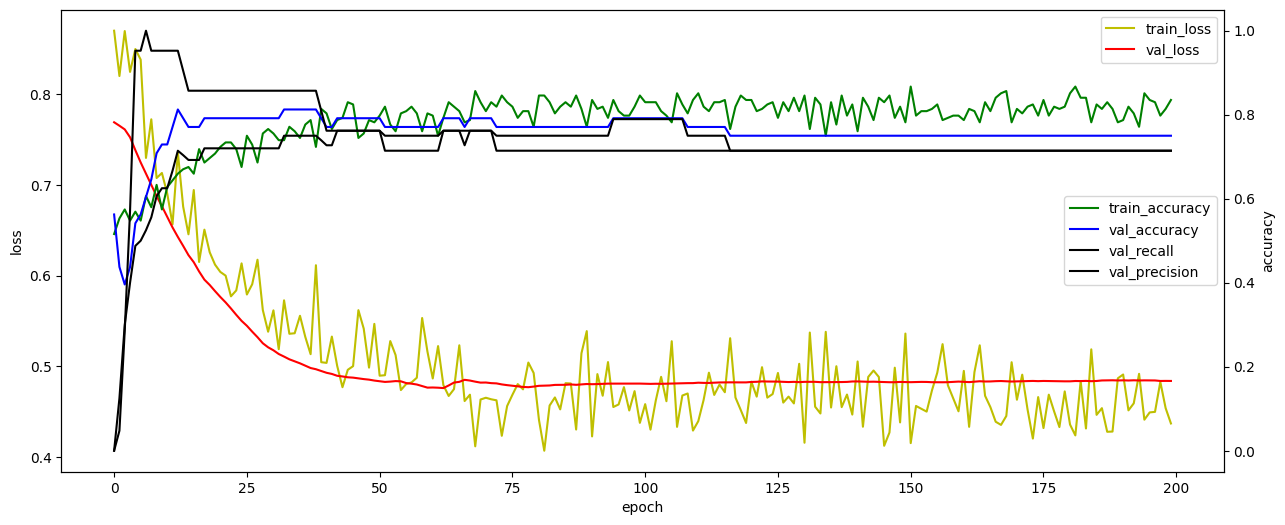

In [98]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.plot(hist.history['val_recall'], 'k', label='val_recall')#recall(검정)
acc_ax.plot(hist.history['val_precision'], 'k', label='val_precision')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()

In [100]:
# 평가 
score= model.evaluate(X_test, y_test)
score
print('model loss:{score[0]}')
print(f'model accuracy: {score[1]*100:.2f}%')
print(f'model recall: {score[2]*100:.2f}%')
print(f'model precision: {score[3]*100:.2f}%')

2/2 [==============================] - 0s 15ms/step - loss: 0.4032 - accuracy: 0.8500 - recall: 0.8571 - precision: 0.8276
model loss:{score[0]}
model accuracy: 85.00%
model recall: 85.71%
model precision: 82.76%


In [102]:
#혼동행렬(교차표) 
# 교차표에서의 실제값: y_test.reshape(-1)


array([1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0], dtype=int64)

In [117]:
y_hat=(model.predict(X_test, verbose=0)>0.5).astype(int).reshape(-1) #예측값을 1차원
#0과 1의 기준값 0.5를 이동하면 recall과 precision이 바뀜
# 0.5=> 0.3 recall 이 좋아짐 
#0.5-> 0.7 precision이 좋아짐 (비추) 

In [118]:
pd.crosstab(y_test.reshape(-1), 
           y_hat, 
           rownames=['실제값'], 
           colnames=['예측값'])

예측값,0,1
실제값,,
0,27,5
1,4,24


In [119]:
confusion_matrix(y_test, y_hat)

array([[27,  5],
       [ 4, 24]], dtype=int64)

## 4.모델 사용
- 저장 / 예측

In [120]:
# 딥러닝 모델 저장시 확장자: h5, keras
model.save('model/06.h5')
save_model(model,'model/06.h5')
model1=load_model('model/06.h5')

In [124]:
data= [[63, 1, 1, 145, 233, 1, 2, 150, 0, 2.3, 3, 0, 6]]
input_data = scaler.transform(data)
(model.predict(input_data)>0.5).astype(int)

1/1 [==============================] - 0s 17ms/step


array([[0]])

# 분류분석
- 1. 데이터셋 생성 & 전처리 
     * X-train, y_train, X_test, y_test-> y_train과 y_test 원핫인코딩
- 2. 모델생성 & 학습과정 설정 & 모델 학습 
- 3. 모델평가(학습과정 시각화, 평가, 교차표 argmax이용) 
- 4. 모델 사용 (저장, 예측) 

## 1. 데이터셋 생성 & 전처리
- y_train, y_test 원핫인코팅 
-  0  -> 1 0
-  1  -> 0 1

In [128]:
Y_train = to_categorical(y_train, 2)
Y_test = to_categorical(y_test)
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((236, 13), (236, 2), (60, 13), (60, 2))

## 2.모델 생성 & 학습과정 설정 & 학습 

In [129]:
model =Sequential(name='sequential')
model.add(Dense(units=32, input_dim=13, activation='relu', 
               kernel_regularizer=l2(0.001))) # L2정규화 (규제) 
model.add(BatchNormalization()) # 출력층의 정규화 
model.add(Dropout(0.4))         #40%를 랜덤하게 꺼서 과적합 방지 
model.add(Dense(units=16, activation='relu',kernel_regularizer=l2(0.001)))
model.add(BatchNormalization()) # 출력층의 정규화 
model.add(Dropout(0.4))         #40%를 랜덤하게 꺼서 과적합 방지 
model.add(Dense(units=8, activation='relu',  kernel_regularizer=l2(0.001)))
model.add(BatchNormalization()) # 출력층의 정규화 
model.add(Dropout(0.2))         #40%를 랜덤하게 꺼서 과적합 방지 
model.add(Dense(units=2, activation='softmax'))#분류분석의 출력층의 활성화 함수 
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_41 (Dense)            (None, 32)                448       
                                                                 
 batch_normalization_12 (Bat  (None, 32)               128       
 chNormalization)                                                
                                                                 
 dropout_13 (Dropout)        (None, 32)                0         
                                                                 
 dense_42 (Dense)            (None, 16)                528       
                                                                 
 batch_normalization_13 (Bat  (None, 16)               64        
 chNormalization)                                                
                                                                 
 dropout_14 (Dropout)        (None, 16)                0

In [131]:
model.compile(loss="categorical_crossentropy", 
             #optimizer=Adam(Learning_rate=0.001), 
             optimizer='adam', 
             metrics=['accuracy', Recall(name='recall'), Precision(name='precision')]
             )

In [132]:
%time
hist=model.fit(X_train, Y_train, 
              epochs=200, 
              validation_split=0.2, 
              class_weight=class_weight_dict, 
              callbacks=[reduce_lr], 
              verbose=1) #0을 하면 안보이니까 1을 일단 넣어야 한다. 

CPU times: total: 0 ns
Wall time: 0 ns
Epoch 1/200
6/6 [==============================] - 2s 96ms/step - loss: 1.0420 - accuracy: 0.5532 - recall: 0.5532 - precision: 0.5532 - val_loss: 0.7383 - val_accuracy: 0.6458 - val_recall: 0.6458 - val_precision: 0.6458 - lr: 0.0010
Epoch 2/200
6/6 [==============================] - 0s 13ms/step - loss: 0.9572 - accuracy: 0.5745 - recall: 0.5745 - precision: 0.5745 - val_loss: 0.7366 - val_accuracy: 0.6042 - val_recall: 0.6042 - val_precision: 0.6042 - lr: 0.0010
Epoch 3/200
6/6 [==============================] - 0s 12ms/step - loss: 0.9758 - accuracy: 0.5585 - recall: 0.5585 - precision: 0.5585 - val_loss: 0.7316 - val_accuracy: 0.6458 - val_recall: 0.6458 - val_precision: 0.6458 - lr: 0.0010
Epoch 4/200
6/6 [==============================] - 0s 13ms/step - loss: 0.9085 - accuracy: 0.5638 - recall: 0.5638 - precision: 0.5638 - val_loss: 0.7261 - val_accuracy: 0.6875 - val_recall: 0.6875 - val_precision: 0.6875 - lr: 0.0010
Epoch 5/200
6/6 [====

Epoch 36/200
6/6 [==============================] - 0s 17ms/step - loss: 0.5274 - accuracy: 0.8138 - recall: 0.8138 - precision: 0.8138 - val_loss: 0.5138 - val_accuracy: 0.8333 - val_recall: 0.8333 - val_precision: 0.8333 - lr: 0.0010
Epoch 37/200
6/6 [==============================] - 0s 14ms/step - loss: 0.5487 - accuracy: 0.7500 - recall: 0.7500 - precision: 0.7500 - val_loss: 0.5101 - val_accuracy: 0.8333 - val_recall: 0.8333 - val_precision: 0.8333 - lr: 0.0010
Epoch 38/200
6/6 [==============================] - 0s 11ms/step - loss: 0.5213 - accuracy: 0.7872 - recall: 0.7872 - precision: 0.7872 - val_loss: 0.5062 - val_accuracy: 0.8333 - val_recall: 0.8333 - val_precision: 0.8333 - lr: 0.0010
Epoch 39/200
6/6 [==============================] - 0s 12ms/step - loss: 0.5704 - accuracy: 0.7553 - recall: 0.7553 - precision: 0.7553 - val_loss: 0.5026 - val_accuracy: 0.8333 - val_recall: 0.8333 - val_precision: 0.8333 - lr: 0.0010
Epoch 40/200
6/6 [==============================] - 0s 1

Epoch 71/200
6/6 [==============================] - 0s 12ms/step - loss: 0.4906 - accuracy: 0.7979 - recall: 0.7979 - precision: 0.7979 - val_loss: 0.4315 - val_accuracy: 0.8750 - val_recall: 0.8750 - val_precision: 0.8750 - lr: 0.0010
Epoch 72/200
6/6 [==============================] - 0s 11ms/step - loss: 0.4855 - accuracy: 0.7926 - recall: 0.7926 - precision: 0.7926 - val_loss: 0.4314 - val_accuracy: 0.8750 - val_recall: 0.8750 - val_precision: 0.8750 - lr: 0.0010
Epoch 73/200
6/6 [==============================] - 0s 12ms/step - loss: 0.4581 - accuracy: 0.8351 - recall: 0.8351 - precision: 0.8351 - val_loss: 0.4304 - val_accuracy: 0.8750 - val_recall: 0.8750 - val_precision: 0.8750 - lr: 0.0010
Epoch 74/200
6/6 [==============================] - 0s 14ms/step - loss: 0.4935 - accuracy: 0.8298 - recall: 0.8298 - precision: 0.8298 - val_loss: 0.4284 - val_accuracy: 0.8750 - val_recall: 0.8750 - val_precision: 0.8750 - lr: 0.0010
Epoch 75/200
6/6 [==============================] - 0s 1

Epoch 106/200
6/6 [==============================] - 0s 13ms/step - loss: 0.4471 - accuracy: 0.8245 - recall: 0.8245 - precision: 0.8245 - val_loss: 0.4136 - val_accuracy: 0.8542 - val_recall: 0.8542 - val_precision: 0.8542 - lr: 5.0000e-04
Epoch 107/200
6/6 [==============================] - 0s 12ms/step - loss: 0.4380 - accuracy: 0.8245 - recall: 0.8245 - precision: 0.8245 - val_loss: 0.4133 - val_accuracy: 0.8542 - val_recall: 0.8542 - val_precision: 0.8542 - lr: 2.5000e-04
Epoch 108/200
6/6 [==============================] - 0s 13ms/step - loss: 0.4375 - accuracy: 0.8351 - recall: 0.8351 - precision: 0.8351 - val_loss: 0.4128 - val_accuracy: 0.8542 - val_recall: 0.8542 - val_precision: 0.8542 - lr: 2.5000e-04
Epoch 109/200
6/6 [==============================] - 0s 13ms/step - loss: 0.4529 - accuracy: 0.8245 - recall: 0.8245 - precision: 0.8245 - val_loss: 0.4127 - val_accuracy: 0.8542 - val_recall: 0.8542 - val_precision: 0.8542 - lr: 2.5000e-04
Epoch 110/200
6/6 [=================

Epoch 140/200
6/6 [==============================] - 0s 12ms/step - loss: 0.5212 - accuracy: 0.7926 - recall: 0.7926 - precision: 0.7926 - val_loss: 0.4112 - val_accuracy: 0.8750 - val_recall: 0.8750 - val_precision: 0.8750 - lr: 1.5625e-05
Epoch 141/200
6/6 [==============================] - 0s 12ms/step - loss: 0.4231 - accuracy: 0.8191 - recall: 0.8191 - precision: 0.8191 - val_loss: 0.4112 - val_accuracy: 0.8750 - val_recall: 0.8750 - val_precision: 0.8750 - lr: 1.5625e-05
Epoch 142/200
6/6 [==============================] - 0s 11ms/step - loss: 0.4644 - accuracy: 0.8191 - recall: 0.8191 - precision: 0.8191 - val_loss: 0.4111 - val_accuracy: 0.8750 - val_recall: 0.8750 - val_precision: 0.8750 - lr: 7.8125e-06
Epoch 143/200
6/6 [==============================] - 0s 13ms/step - loss: 0.4491 - accuracy: 0.8404 - recall: 0.8404 - precision: 0.8404 - val_loss: 0.4109 - val_accuracy: 0.8750 - val_recall: 0.8750 - val_precision: 0.8750 - lr: 7.8125e-06
Epoch 144/200
6/6 [=================

Epoch 174/200
6/6 [==============================] - 0s 18ms/step - loss: 0.4594 - accuracy: 0.8245 - recall: 0.8245 - precision: 0.8245 - val_loss: 0.4102 - val_accuracy: 0.8750 - val_recall: 0.8750 - val_precision: 0.8750 - lr: 1.0000e-06
Epoch 175/200
6/6 [==============================] - 0s 14ms/step - loss: 0.4584 - accuracy: 0.8404 - recall: 0.8404 - precision: 0.8404 - val_loss: 0.4102 - val_accuracy: 0.8750 - val_recall: 0.8750 - val_precision: 0.8750 - lr: 1.0000e-06
Epoch 176/200
6/6 [==============================] - 0s 17ms/step - loss: 0.4564 - accuracy: 0.8564 - recall: 0.8564 - precision: 0.8564 - val_loss: 0.4103 - val_accuracy: 0.8750 - val_recall: 0.8750 - val_precision: 0.8750 - lr: 1.0000e-06
Epoch 177/200
6/6 [==============================] - 0s 17ms/step - loss: 0.4715 - accuracy: 0.8457 - recall: 0.8457 - precision: 0.8457 - val_loss: 0.4102 - val_accuracy: 0.8750 - val_recall: 0.8750 - val_precision: 0.8750 - lr: 1.0000e-06
Epoch 178/200
6/6 [=================

## 3. 모델평가(시각화, 평가, 그래프) 

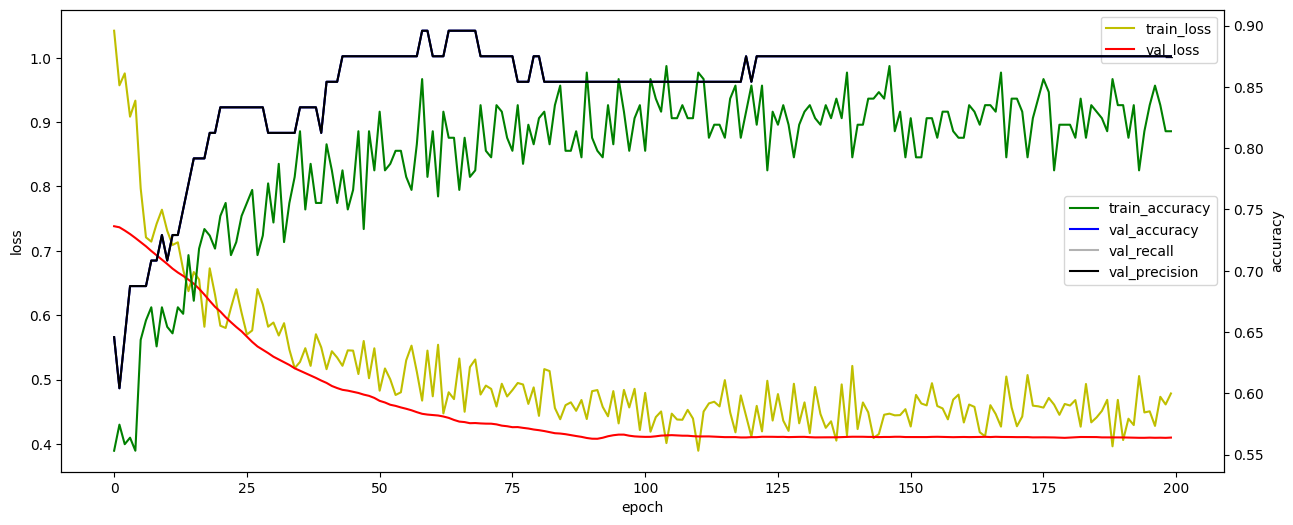

In [141]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.plot(hist.history['val_recall'], 'k', label='val_recall', alpha=0.3)#recall(검정)
acc_ax.plot(hist.history['val_precision'], 'k', label='val_precision')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()

In [143]:
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test, verbose=0)
print('model loss:', loss)
print(f'model accuracy:{accuracy*100:.2f}%')
print(f'model precision:{precision*100:.2f}%')
print(f'model recall:{recall*100:.2f}%')

model loss: 0.39382216334342957
model accuracy:86.67%
model precision:86.67%
model recall:86.67%


In [ ]:
#교차표에서 실제값
Y_test.argmax(axis=1)
y_test.reshape(-1)


In [144]:
#예측값
y_hat=model.predict(X_test).argmax(axis=1)
y_hat

2/2 [==============================] - 0s 4ms/step


array([1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0], dtype=int64)

In [146]:
pd.crosstab(y_test.reshape(-1), y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1
실제값,,
0,27,5
1,3,25


In [147]:
confusion_matrix(y_test, y_hat)

array([[27,  5],
       [ 3, 25]], dtype=int64)

## 4. 모델 사용
- 저장/예측

In [149]:
model.save('model/06.h5')
save_model(model,'model/06.h5')
model1=load_model('model/06.h5')

In [153]:
data=[[63, 1, 1, 145, 233, 1, 2, 150, 0, 2.3, 3, 0, 6],
       [67, 1, 4, 160, 286, 0, 0, 108, 1, 1.5, 2, 3, 3]]
input_data= scaler.transform(data)
model.predict(input_data)#.argmax(axis=1)

1/1 [==============================] - 0s 23ms/step


array([[0.7992604 , 0.20073956],
       [0.03553118, 0.9644688 ]], dtype=float32)

In [148]:
X[:2]

array([[63, 1, 1, 145, 233, 1, 2, 150, 0, 2.3, 3, 0, 6],
       [67, 1, 4, 160, 286, 0, 0, 108, 1, 1.5, 2, 3, 3]], dtype=object)